---
## Task 2: MNIST Handwritten Digit Classification with SGD
Load the MNIST dataset and build a neural network with SGD optimizer to classify digits 0–9.

In [1]:
# import libraries
import tensorflow as tf
from tensorflow import keras                  # High-level Keras API
from tensorflow.keras import layers          # Layer definitions (Dense, etc.)

# Numerical computing
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
# Load the built-in MNIST dataset (60,000 train / 10,000 test images)
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

In [3]:
# normalizing the pixel values of the pictures
# Normalize pixel values from [0, 255] to [0.0, 1.0]
X_train_mnist = X_train_mnist / 255.0
X_test_mnist  = X_test_mnist  / 255.0

# Flatten 28x28 images into 784-element vectors (required for Dense layers)
X_train_flat = X_train_mnist.reshape(-1, 784)
X_test_flat  = X_test_mnist.reshape(-1, 784)

In [4]:
# Build the neural network
model_mnist = keras.Sequential([
    layers.Dense(128, activation='relu',    input_shape=(784,)),  # Hidden layer 1
    layers.Dense(64,  activation='relu'),                          # Hidden layer 2
    layers.Dense(10,  activation='softmax')                        # Output: 10 digit classes
])

c:\Users\shafi\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile with SGD optimizer
# sparse_categorical_crossentropy: used when labels are integers (not one-hot)
model_mnist.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Train for 5 epochs (increase for better accuracy)
history_mnist = model_mnist.fit(
    X_train_flat, y_train_mnist,
    epochs=5,
    validation_data=(X_test_flat, y_test_mnist),
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8383 - loss: 0.6081 - val_accuracy: 0.9081 - val_loss: 0.3199
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9167 - loss: 0.2897 - val_accuracy: 0.9282 - val_loss: 0.2492
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9315 - loss: 0.2372 - val_accuracy: 0.9405 - val_loss: 0.2111
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9414 - loss: 0.2033 - val_accuracy: 0.9457 - val_loss: 0.1848
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9491 - loss: 0.1787 - val_accuracy: 0.9487 - val_loss: 0.1727


In [7]:
# Final test accuracy
_, test_acc = model_mnist.evaluate(X_test_flat, y_test_mnist, verbose=0)
print(f"\nMNIST Test Accuracy: {test_acc*100:.2f}%")



MNIST Test Accuracy: 94.87%


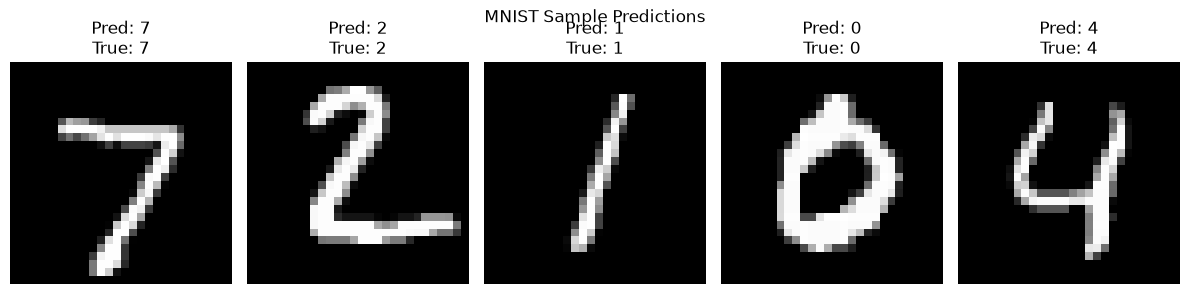

In [8]:
# Visualize a few predictions
predictions = model_mnist.predict(X_test_flat[:5], verbose=0)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test_mnist[i], cmap='gray')
    ax.set_title(f"Pred: {np.argmax(predictions[i])}\nTrue: {y_test_mnist[i]}")
    ax.axis('off')
plt.suptitle("MNIST Sample Predictions")
plt.tight_layout()
plt.show()